# Matrix Profile Study Summary, 2025

This notebook summarizes the Matrix Profile based motif discovery work for the master's thesis.

## Objectives

This notebook performs motif discovery on one-minute BTCUSDT financial data for the year 2025 using three representations:

1. **Raw univariate representation**
   - raw `close`

2. **Engineered univariate representations**
   - one feature at a time, including `log_return`, `rolling_volatility`, `hl_range`, and `volume_zscore`

3. **Multivariate representation**
   - joint motif discovery using multiple engineered channels with `stumpy.mstump`

## Main goals

- compute Matrix Profiles on 2025 one-minute data
- extract top-k non-overlapping motifs
- compare motifs across raw, univariate-feature, and multivariate settings
- identify common motif dates across representations
- visualize motif windows clearly
- build a structured motif log for thesis reporting
- compare discovered motif dates with external market events

## Thesis relevance

The purpose is not only to find repeated subsequences, but to understand:

- whether motifs remain stable across representations
- whether multivariate motifs are more meaningful than raw-price motifs
- whether recurring motifs align with real external market conditions or event-driven periods

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
import stumpy

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 120

In [2]:
# =========================
# CONFIG
# =========================

ASSET = "BTCUSDT"
YEAR = 2025

TOP_K = 10
RUN_MODE = "full"  # options: "debug", "month_test", "full"
DEBUG_ROWS = 20_000

# Main window lengths in minutes. With one-minute data, m equals minutes.
WINDOWS_RAW_CLOSE = [60, 240, 480, 720, 1440]
WINDOWS_UNIVARIATE = [60, 240, 480, 720, 1440]
WINDOWS_MULTIVARIATE = [60, 240, 480, 720, 1440]

# Selected engineered features for univariate and multivariate analysis.
CANDIDATE_FEATURES = [
    "log_return",
    "rolling_volatility",
    "hl_range",
    "volume_zscore",
]

# Feature construction choices.
ROLLING_VOL_WINDOW_MINUTES = 60
VOLUME_ZSCORE_WINDOW_MINUTES = 1440

# Overlap policy.
MIN_SEPARATION_MULTIPLIER = 1.0  # 1.0 means at least one full window apart.

# Motif commonality tolerance in minutes.
COMMON_MOTIF_TOLERANCE_MINUTES = 60

# External event matching tolerance.
EVENT_TOLERANCE_HOURS = 24

# Prefer the processed one-minute BTCUSDT parquet in this repository.
DATA_RELATIVE_CANDIDATES = [
    Path("data") / "processed" / "crypto" / "1min" / f"{ASSET}_1m_processed.parquet",
    Path("data") / "processed" / f"{ASSET}_1m_processed.parquet",
    Path("data") / "processed" / f"{ASSET}.parquet",
]

EXTERNAL_EVENT_RELATIVE_CANDIDATES = [
    Path("data") / "external" / f"{ASSET}_{YEAR}_events.csv",
    Path("data") / "external" / "crypto_2025_events.csv",
    Path("data") / "external" / "external_events.csv",
]

In [3]:
def find_project_root(start: Optional[Path] = None) -> Path:
    '''Find the repository root from either the notebook directory or the repo root.'''
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        has_data = (candidate / "data").exists()
        has_notebooks = (candidate / "notebooks").exists()
        if has_data and has_notebooks:
            return candidate
    raise FileNotFoundError(f"Could not locate project root from {start}")


PROJECT_ROOT = find_project_root()
DATA_CANDIDATES = [PROJECT_ROOT / p for p in DATA_RELATIVE_CANDIDATES]
EXTERNAL_EVENT_CANDIDATES = [PROJECT_ROOT / p for p in EXTERNAL_EVENT_RELATIVE_CANDIDATES]

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "matrix_profile_summary" / ASSET / str(YEAR)
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("RUN_MODE:", RUN_MODE)

PROJECT_ROOT: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis
OUTPUT_DIR: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\outputs\matrix_profile_summary\BTCUSDT\2025
RUN_MODE: full


In [4]:
def find_existing_file(candidates: List[Path]) -> Path:
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "No dataset found. Checked:\n" + "\n".join(str(p) for p in candidates)
    )


def load_data(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported file type: {path.suffix}")


def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "timestamp" not in df.columns:
        raise ValueError("Expected a 'timestamp' column in processed dataset.")

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp")
    df = df.drop_duplicates("timestamp", keep="last")

    numeric_cols = [c for c in df.columns if c != "timestamp"]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df.reset_index(drop=True)


def slice_to_year(df: pd.DataFrame, year: int) -> pd.DataFrame:
    start = pd.Timestamp(f"{year}-01-01 00:00:00", tz="UTC")
    end = pd.Timestamp(f"{year + 1}-01-01 00:00:00", tz="UTC")
    out = df[(df["timestamp"] >= start) & (df["timestamp"] < end)].copy()
    return out.reset_index(drop=True)


def apply_run_mode(df: pd.DataFrame, run_mode: str) -> pd.DataFrame:
    if run_mode == "debug":
        return df.iloc[: min(len(df), DEBUG_ROWS)].copy()
    if run_mode == "month_test":
        if df.empty:
            return df.copy()
        first_ts = df["timestamp"].min()
        cutoff = first_ts + pd.Timedelta(days=31)
        return df[df["timestamp"] < cutoff].copy()
    if run_mode == "full":
        return df.copy()
    raise ValueError(f"Unknown RUN_MODE: {run_mode}")


def infer_freq_minutes(df: pd.DataFrame) -> Optional[float]:
    if len(df) < 3 or "timestamp" not in df.columns:
        return None
    deltas = df["timestamp"].diff().dropna().dt.total_seconds() / 60
    if deltas.empty:
        return None
    return float(deltas.mode().iloc[0])


def basic_qc_summary(df: pd.DataFrame, year: int) -> pd.DataFrame:
    expected_rows = 366 * 24 * 60 if pd.Timestamp(f"{year}-12-31").is_leap_year else 365 * 24 * 60
    freq_min = infer_freq_minutes(df)
    observed_unique = df["timestamp"].nunique() if "timestamp" in df.columns else 0
    summary = {
        "rows": len(df),
        "expected_full_year_rows": expected_rows,
        "row_coverage_fraction": len(df) / expected_rows if expected_rows else np.nan,
        "unique_timestamps": observed_unique,
        "start": df["timestamp"].min() if "timestamp" in df.columns and not df.empty else pd.NaT,
        "end": df["timestamp"].max() if "timestamp" in df.columns and not df.empty else pd.NaT,
        "inferred_freq_minutes": freq_min,
        "missing_timestamps": df["timestamp"].isna().sum() if "timestamp" in df.columns else np.nan,
        "duplicate_timestamps": len(df) - observed_unique,
    }
    return pd.DataFrame([summary])

In [5]:
data_path = find_existing_file(DATA_CANDIDATES)
print("Using dataset:", data_path)

df = load_data(data_path)
df = standardize_df(df)
df = slice_to_year(df, YEAR)
df = apply_run_mode(df, RUN_MODE).reset_index(drop=True)

if df.empty:
    raise ValueError(f"No rows available for {ASSET} in {YEAR} after applying RUN_MODE={RUN_MODE}.")

qc = basic_qc_summary(df, YEAR)
display(qc)

print("Columns:")
print(df.columns.tolist())

display(df.head())
display(df.tail())

Using dataset: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\crypto\1min\BTCUSDT_1m_processed.parquet


,rows,expected_full_year_rows,row_coverage_fraction,unique_timestamps,start,end,inferred_freq_minutes,missing_timestamps,duplicate_timestamps
0,525600,525600,1.0,525600,2025-01-01 00:00:00+00:00,2025-12-31 23:59:00+00:00,1.0,0,0


Columns:
['timestamp', 'open', 'high', 'low', 'close', 'volume', 'log_return', 'pct_return', 'volatility_30m', 'volatility_60m', 'volatility_240m', 'realized_volatility_60m']


,timestamp,open,high,low,close,volume,log_return,pct_return,volatility_30m,volatility_60m,volatility_240m,realized_volatility_60m
0,2025-01-01 00:00:00+00:00,93576.00,93610.93,93537.50,93610.93,8.21827,0.000373,0.000373,0.000370,0.000416,0.000484,0.003207
1,2025-01-01 00:01:00+00:00,93610.93,93652.00,93606.20,93652.00,12.14029,0.000439,0.000439,0.000345,0.000417,0.000484,0.003223
2,2025-01-01 00:02:00+00:00,93652.00,93702.15,93635.98,93702.15,11.60597,0.000535,0.000535,0.000355,0.000416,0.000486,0.003208
3,2025-01-01 00:03:00+00:00,93702.14,93702.15,93654.48,93677.98,8.72958,-0.000258,-0.000258,0.000324,0.000415,0.000486,0.003200
4,2025-01-01 00:04:00+00:00,93677.98,93677.99,93659.92,93661.20,5.24749,-0.000179,-0.000179,0.000326,0.000396,0.000485,0.003057


,timestamp,open,high,low,close,volume,log_return,pct_return,volatility_30m,volatility_60m,volatility_240m,realized_volatility_60m
525595,2025-12-31 23:55:00+00:00,87641.15,87652.53,87641.14,87652.52,1.99843,1.298393e-04,1.298477e-04,0.000136,0.000156,0.000258,0.001200
525596,2025-12-31 23:56:00+00:00,87652.53,87655.31,87652.52,87655.30,0.67375,3.171564e-05,3.171614e-05,0.000135,0.000154,0.000258,0.001186
525597,2025-12-31 23:57:00+00:00,87655.30,87655.31,87642.88,87642.89,3.94470,-1.415873e-04,-1.415773e-04,0.000134,0.000154,0.000258,0.001187
525598,2025-12-31 23:58:00+00:00,87642.89,87642.93,87642.88,87642.93,7.30751,4.563974e-07,4.563975e-07,0.000134,0.000151,0.000258,0.001165
525599,2025-12-31 23:59:00+00:00,87642.92,87648.22,87642.92,87648.22,4.28052,6.035673e-05,6.035855e-05,0.000135,0.000151,0.000254,0.001162


In [6]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    '''Create the common thesis features if they are absent from the processed dataset.'''
    out = df.copy()

    required_ohlcv = {"open", "high", "low", "close", "volume"}
    missing_ohlcv = sorted(required_ohlcv - set(out.columns))
    if missing_ohlcv:
        raise ValueError(f"Missing required OHLCV columns: {missing_ohlcv}")

    if "log_return" not in out.columns:
        out["log_return"] = np.log(out["close"]).diff()

    if "pct_return" not in out.columns:
        out["pct_return"] = out["close"].pct_change()

    if "hl_range" not in out.columns:
        out["hl_range"] = (out["high"] - out["low"]) / out["close"].replace(0, np.nan)

    if "rolling_volatility" not in out.columns:
        preferred_vol_cols = [
            "volatility_60m",
            "realized_volatility_60m",
            "volatility_30m",
            "volatility_240m",
        ]
        source_col = next((c for c in preferred_vol_cols if c in out.columns), None)
        if source_col is not None:
            out["rolling_volatility"] = out[source_col]
            out["rolling_volatility_source"] = source_col
        else:
            out["rolling_volatility"] = out["log_return"].rolling(
                ROLLING_VOL_WINDOW_MINUTES, min_periods=ROLLING_VOL_WINDOW_MINUTES
            ).std()
            out["rolling_volatility_source"] = f"log_return_rolling_{ROLLING_VOL_WINDOW_MINUTES}m_std"

    if "volume_zscore" not in out.columns:
        volume_mean = out["volume"].rolling(
            VOLUME_ZSCORE_WINDOW_MINUTES, min_periods=VOLUME_ZSCORE_WINDOW_MINUTES
        ).mean()
        volume_std = out["volume"].rolling(
            VOLUME_ZSCORE_WINDOW_MINUTES, min_periods=VOLUME_ZSCORE_WINDOW_MINUTES
        ).std()
        out["volume_zscore"] = (out["volume"] - volume_mean) / volume_std.replace(0, np.nan)

    engineered_cols = ["log_return", "rolling_volatility", "hl_range", "volume_zscore"]
    for col in engineered_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

    return out


df = add_engineered_features(df)
available_features = [f for f in CANDIDATE_FEATURES if f in df.columns]

print("Available engineered features:", available_features)
if "rolling_volatility_source" in df.columns:
    print("rolling_volatility source:", df["rolling_volatility_source"].dropna().iloc[0])

display(df[["timestamp", "close", "volume"] + available_features].head(10))

Available engineered features: ['log_return', 'rolling_volatility', 'hl_range', 'volume_zscore']
rolling_volatility source: volatility_60m


,timestamp,close,volume,log_return,rolling_volatility,hl_range,volume_zscore
0,2025-01-01 00:00:00+00:00,93610.93,8.21827,0.000373,0.000416,0.000784,NaN
1,2025-01-01 00:01:00+00:00,93652.00,12.14029,0.000439,0.000417,0.000489,NaN
2,2025-01-01 00:02:00+00:00,93702.15,11.60597,0.000535,0.000416,0.000706,NaN
3,2025-01-01 00:03:00+00:00,93677.98,8.72958,-0.000258,0.000415,0.000509,NaN
4,2025-01-01 00:04:00+00:00,93661.20,5.24749,-0.000179,0.000396,0.000193,NaN
5,2025-01-01 00:05:00+00:00,93678.01,5.08788,0.000179,0.000393,0.000180,NaN
6,2025-01-01 00:06:00+00:00,93632.05,30.37050,-0.000491,0.000398,0.000833,NaN
7,2025-01-01 00:07:00+00:00,93612.01,13.39197,-0.000214,0.000388,0.000238,NaN
8,2025-01-01 00:08:00+00:00,93611.84,10.73540,-0.000002,0.000388,0.000076,NaN
9,2025-01-01 00:09:00+00:00,93607.10,12.36010,-0.000051,0.000346,0.000052,NaN


In [7]:
missing_summary = (
    df.isna().mean()
      .sort_values(ascending=False)
      .rename("missing_fraction")
      .to_frame()
)

display(missing_summary.head(25))

feature_qc = pd.DataFrame({
    "feature": available_features,
    "usable_rows": [df[f].replace([np.inf, -np.inf], np.nan).notna().sum() for f in available_features],
    "missing_fraction": [df[f].replace([np.inf, -np.inf], np.nan).isna().mean() for f in available_features],
})

display(feature_qc)

,missing_fraction
volume_zscore,0.002738
timestamp,0.000000
high,0.000000
open,0.000000
close,0.000000
volume,0.000000
log_return,0.000000
low,0.000000
pct_return,0.000000
volatility_30m,0.000000


,feature,usable_rows,missing_fraction
0,log_return,525600,0.000000
1,rolling_volatility,525600,0.000000
2,hl_range,525600,0.000000
3,volume_zscore,524161,0.002738


In [8]:
def z_normalize(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if np.isnan(sd) or sd == 0:
        return np.zeros_like(x, dtype=float)
    return (x - mu) / sd


def clean_series_for_mp(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)


def prepare_univariate_series(df: pd.DataFrame, col: str) -> pd.DataFrame:
    if col not in df.columns:
        raise KeyError(f"Column not found: {col}")
    out = df[["timestamp", col]].copy()
    out[col] = clean_series_for_mp(out[col])
    out = out.dropna(subset=[col]).reset_index(drop=True)
    return out


def prepare_multivariate_df(df: pd.DataFrame, features: List[str]) -> pd.DataFrame:
    missing = [c for c in features if c not in df.columns]
    if missing:
        raise KeyError(f"Missing multivariate features: {missing}")
    out = df[["timestamp"] + features].copy()
    for c in features:
        out[c] = clean_series_for_mp(out[c])
    out = out.dropna(subset=features).reset_index(drop=True)
    return out


def profile_values_from_stump(mp: np.ndarray) -> np.ndarray:
    return np.asarray(mp[:, 0], dtype=float)

In [9]:
def compute_stump_profile(series: np.ndarray, m: int) -> np.ndarray:
    series = np.asarray(series, dtype=float)
    if len(series) <= m + 1:
        raise ValueError(f"Series length {len(series)} is too short for window m={m}")
    return stumpy.stump(series, m)


def compute_mstump_profile(matrix_2d: np.ndarray, m: int) -> Tuple[np.ndarray, np.ndarray]:
    '''
    Input shape for mstump: (n_dimensions, n_timestamps).

    Returns:
        P: matrix profile values, shape (n_dimensions, n_timestamps - m + 1)
        I: matrix profile indices, shape (n_dimensions, n_timestamps - m + 1)
    '''
    matrix_2d = np.asarray(matrix_2d, dtype=float)
    if matrix_2d.ndim != 2:
        raise ValueError("matrix_2d must have shape (n_dimensions, n_timestamps)")
    if matrix_2d.shape[1] <= m + 1:
        raise ValueError(f"Time dimension {matrix_2d.shape[1]} is too short for window m={m}")
    P, I = stumpy.mstump(matrix_2d, m=m)
    return P, I


def extract_top_k_motifs_univariate(
    mp: np.ndarray,
    timestamps: pd.Series,
    m: int,
    top_k: int = 10,
    min_sep_multiplier: float = 1.0,
) -> pd.DataFrame:
    '''
    Extract top-k non-overlapping motif pairs from STUMP output.

    mp[:, 0] = profile value
    mp[:, 1] = nearest-neighbor index
    '''
    profile_values = np.asarray(mp[:, 0], dtype=float)
    nn_idx = np.asarray(mp[:, 1], dtype=float)

    valid = np.isfinite(profile_values) & np.isfinite(nn_idx) & (nn_idx >= 0)
    candidate_idx = np.where(valid)[0]
    candidate_idx = candidate_idx[np.argsort(profile_values[candidate_idx])]

    selected = []
    occupied = []
    min_sep = int(np.ceil(m * min_sep_multiplier))
    max_start = len(timestamps) - m

    def overlaps_existing(i: int, j: int) -> bool:
        for a, b in occupied:
            if (
                abs(i - a) < min_sep
                or abs(i - b) < min_sep
                or abs(j - a) < min_sep
                or abs(j - b) < min_sep
            ):
                return True
        return False

    for i in candidate_idx:
        j = int(nn_idx[i])
        i = int(i)
        if i < 0 or i > max_start or j < 0 or j > max_start:
            continue
        if overlaps_existing(i, j):
            continue

        selected.append({
            "rank": len(selected) + 1,
            "window_size": int(m),
            "motif_index": i,
            "neighbor_index": j,
            "motif_start": timestamps.iloc[i],
            "motif_end": timestamps.iloc[i + m - 1],
            "neighbor_start": timestamps.iloc[j],
            "neighbor_end": timestamps.iloc[j + m - 1],
            "profile_value": float(profile_values[i]),
        })
        occupied.append((i, j))

        if len(selected) >= top_k:
            break

    return pd.DataFrame(selected)


def extract_top_k_motifs_multivariate(
    P: np.ndarray,
    I: np.ndarray,
    timestamps: pd.Series,
    m: int,
    top_k: int = 10,
    min_sep_multiplier: float = 1.0,
) -> pd.DataFrame:
    '''Extract top-k non-overlapping full-dimensional motif pairs from MSTUMP output.'''
    full_dim_profile = np.asarray(P[-1], dtype=float)
    full_dim_indices = np.asarray(I[-1], dtype=float)

    valid = np.isfinite(full_dim_profile) & np.isfinite(full_dim_indices) & (full_dim_indices >= 0)
    candidate_idx = np.where(valid)[0]
    candidate_idx = candidate_idx[np.argsort(full_dim_profile[candidate_idx])]

    selected = []
    occupied = []
    min_sep = int(np.ceil(m * min_sep_multiplier))
    max_start = len(timestamps) - m

    def overlaps_existing(i: int, j: int) -> bool:
        for a, b in occupied:
            if (
                abs(i - a) < min_sep
                or abs(i - b) < min_sep
                or abs(j - a) < min_sep
                or abs(j - b) < min_sep
            ):
                return True
        return False

    for i in candidate_idx:
        j = int(full_dim_indices[i])
        i = int(i)
        if i < 0 or i > max_start or j < 0 or j > max_start:
            continue
        if overlaps_existing(i, j):
            continue

        selected.append({
            "rank": len(selected) + 1,
            "window_size": int(m),
            "motif_index": i,
            "neighbor_index": j,
            "motif_start": timestamps.iloc[i],
            "motif_end": timestamps.iloc[i + m - 1],
            "neighbor_start": timestamps.iloc[j],
            "neighbor_end": timestamps.iloc[j + m - 1],
            "profile_value": float(full_dim_profile[i]),
        })
        occupied.append((i, j))

        if len(selected) >= top_k:
            break

    return pd.DataFrame(selected)

In [10]:
def add_simple_volatility_regime(df: pd.DataFrame, vol_col: str = "rolling_volatility") -> pd.DataFrame:
    out = df.copy()

    if vol_col not in out.columns:
        out["vol_regime"] = "unknown"
        return out

    s = pd.to_numeric(out[vol_col], errors="coerce")
    q1 = s.quantile(0.33)
    q2 = s.quantile(0.66)

    def label(x: float) -> str:
        if pd.isna(x):
            return "unknown"
        if x <= q1:
            return "low_vol"
        if x <= q2:
            return "mid_vol"
        return "high_vol"

    out["vol_regime"] = s.apply(label)
    return out


df = add_simple_volatility_regime(df)
display(df[["timestamp", "vol_regime", "rolling_volatility"]].head())
display(df["vol_regime"].value_counts(dropna=False).rename_axis("vol_regime").to_frame("rows"))

,timestamp,vol_regime,rolling_volatility
0,2025-01-01 00:00:00+00:00,mid_vol,0.000416
1,2025-01-01 00:01:00+00:00,mid_vol,0.000417
2,2025-01-01 00:02:00+00:00,mid_vol,0.000416
3,2025-01-01 00:03:00+00:00,mid_vol,0.000415
4,2025-01-01 00:04:00+00:00,mid_vol,0.000396


,rows
vol_regime,
high_vol,178704
mid_vol,173448
low_vol,173448


In [11]:
def annotate_motif_regimes(motif_df: pd.DataFrame, df_ref: pd.DataFrame) -> pd.DataFrame:
    if motif_df.empty:
        return motif_df.copy()
    if "vol_regime" not in df_ref.columns:
        out = motif_df.copy()
        out["motif_regime"] = "unknown"
        out["neighbor_regime"] = "unknown"
        out["same_regime_flag"] = False
        return out

    regime_lookup = df_ref[["timestamp", "vol_regime"]].drop_duplicates("timestamp")
    ts_to_regime = regime_lookup.set_index("timestamp")["vol_regime"].to_dict()

    out = motif_df.copy()
    out["motif_regime"] = out["motif_start"].map(ts_to_regime).fillna("unknown")
    out["neighbor_regime"] = out["neighbor_start"].map(ts_to_regime).fillna("unknown")
    out["same_regime_flag"] = out["motif_regime"] == out["neighbor_regime"]
    return out

In [12]:
def nice_window_label(m: int, freq_minutes: float = 1.0) -> str:
    total_minutes = m * freq_minutes
    if total_minutes < 60:
        return f"{int(total_minutes)} Min"
    if total_minutes < 60 * 24:
        return f"{total_minutes / 60:g} Hour"
    return f"{total_minutes / (60 * 24):.1f} Day"


def plot_multiscale_profiles(
    timestamps: pd.Series,
    signal: pd.Series,
    profiles: Dict[int, np.ndarray],
    title: str,
    save_path: Optional[Path] = None,
    freq_minutes: float = 1.0,
):
    n_panels = 1 + len(profiles)
    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=(16, max(3, 2.8 * n_panels)),
        sharex=True,
        gridspec_kw={"hspace": 0.25},
    )

    if n_panels == 1:
        axes = [axes]

    axes[0].plot(timestamps, signal, linewidth=0.8)
    axes[0].set_title(f"{title} | Original Series", fontsize=12)
    axes[0].set_ylabel("value")

    for ax, (m, profile_vals) in zip(axes[1:], profiles.items()):
        profile_vals = np.asarray(profile_vals, dtype=float)
        valid_len = min(len(timestamps), len(profile_vals))
        ax.plot(timestamps.iloc[:valid_len], profile_vals[:valid_len], linewidth=0.8)
        ax.set_title(f"{nice_window_label(m, freq_minutes)} Matrix Profile", fontsize=11)
        ax.set_ylabel("distance")

    axes[-1].set_xlabel("Datetime")
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

In [13]:
def plot_motif_highlight(
    df_signal: pd.DataFrame,
    value_col: str,
    motif_row: pd.Series,
    title_prefix: str = "",
    save_path: Optional[Path] = None,
):
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(df_signal["timestamp"], df_signal[value_col], linewidth=0.8)

    ax.axvspan(motif_row["motif_start"], motif_row["motif_end"], alpha=0.25, label="Motif")
    ax.axvspan(motif_row["neighbor_start"], motif_row["neighbor_end"], alpha=0.25, label="Nearest neighbor")

    ax.set_title(
        f"{title_prefix} | rank={motif_row['rank']} | m={motif_row['window_size']} | MP={motif_row['profile_value']:.4f}"
    )
    ax.set_ylabel(value_col)
    ax.legend()
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


def plot_univariate_motif_overlay(
    df_signal: pd.DataFrame,
    value_col: str,
    motif_row: pd.Series,
    save_path: Optional[Path] = None,
):
    m = int(motif_row["window_size"])
    i = int(motif_row["motif_index"])
    j = int(motif_row["neighbor_index"])

    seq_a = z_normalize(df_signal[value_col].iloc[i : i + m].to_numpy())
    seq_b = z_normalize(df_signal[value_col].iloc[j : j + m].to_numpy())

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(seq_a, label=f"Motif | {motif_row['motif_start']}")
    ax.plot(seq_b, label=f"Neighbor | {motif_row['neighbor_start']}")
    ax.set_title(f"Overlay | rank={motif_row['rank']} | m={m} | MP={motif_row['profile_value']:.4f}")
    ax.set_xlabel("Minutes from motif start")
    ax.set_ylabel("z-normalized value")
    ax.legend()
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


def plot_multivariate_motif_panel(
    df_multi: pd.DataFrame,
    features: List[str],
    motif_row: pd.Series,
    save_path: Optional[Path] = None,
):
    m = int(motif_row["window_size"])
    i = int(motif_row["motif_index"])
    j = int(motif_row["neighbor_index"])

    n = len(features)
    fig, axes = plt.subplots(n, 1, figsize=(12, max(3, 3 * n)), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, feat in zip(axes, features):
        seq_a = z_normalize(df_multi[feat].iloc[i : i + m].to_numpy())
        seq_b = z_normalize(df_multi[feat].iloc[j : j + m].to_numpy())

        ax.plot(seq_a, label=f"Motif | {motif_row['motif_start']}")
        ax.plot(seq_b, label=f"Neighbor | {motif_row['neighbor_start']}")
        ax.set_title(feat)
        ax.set_ylabel("z-score")
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Minutes from motif start")
    fig.suptitle(
        f"Multivariate Motif Panel | rank={motif_row['rank']} | m={m} | MP={motif_row['profile_value']:.4f}",
        y=1.02,
    )
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

In [14]:
def build_occurrence_table(motif_df: pd.DataFrame, representation_name: str) -> pd.DataFrame:
    if motif_df.empty:
        return pd.DataFrame()

    rows = []
    for _, r in motif_df.iterrows():
        rows.append({
            "representation": representation_name,
            "rank": int(r["rank"]),
            "window_size": int(r["window_size"]),
            "occurrence_type": "motif",
            "start": r["motif_start"],
            "end": r["motif_end"],
            "profile_value": float(r["profile_value"]),
        })
        rows.append({
            "representation": representation_name,
            "rank": int(r["rank"]),
            "window_size": int(r["window_size"]),
            "occurrence_type": "neighbor",
            "start": r["neighbor_start"],
            "end": r["neighbor_end"],
            "profile_value": float(r["profile_value"]),
        })
    return pd.DataFrame(rows)


def find_common_motifs(
    occurrence_tables: Dict[str, pd.DataFrame],
    tolerance_minutes: int = 60,
) -> pd.DataFrame:
    reps = list(occurrence_tables.keys())
    out = []
    tolerance = pd.Timedelta(minutes=tolerance_minutes)

    for i in range(len(reps)):
        for j in range(i + 1, len(reps)):
            a_name, b_name = reps[i], reps[j]
            a_df = occurrence_tables[a_name]
            b_df = occurrence_tables[b_name]

            if a_df.empty or b_df.empty:
                continue

            for _, ra in a_df.iterrows():
                for _, rb in b_df.iterrows():
                    gap = abs(ra["start"] - rb["start"])
                    if gap <= tolerance:
                        out.append({
                            "rep_a": a_name,
                            "rep_b": b_name,
                            "start_a": ra["start"],
                            "start_b": rb["start"],
                            "gap_minutes": gap.total_seconds() / 60,
                            "window_a": int(ra["window_size"]),
                            "window_b": int(rb["window_size"]),
                            "rank_a": int(ra["rank"]),
                            "rank_b": int(rb["rank"]),
                            "occurrence_type_a": ra["occurrence_type"],
                            "occurrence_type_b": rb["occurrence_type"],
                        })

    if not out:
        return pd.DataFrame(columns=[
            "rep_a", "rep_b", "start_a", "start_b", "gap_minutes", "window_a", "window_b",
            "rank_a", "rank_b", "occurrence_type_a", "occurrence_type_b",
        ])

    return pd.DataFrame(out).sort_values("gap_minutes").reset_index(drop=True)

In [15]:
def load_external_events() -> pd.DataFrame:
    '''
    Load external events if a CSV exists, otherwise return a clearly labeled template.

    Expected CSV columns:
    - event_time: UTC-compatible timestamp
    - event_name: event label
    - category: event category
    '''
    existing = [p for p in EXTERNAL_EVENT_CANDIDATES if p.exists()]
    if existing:
        event_path = existing[0]
        print("Using external events file:", event_path)
        ev = pd.read_csv(event_path)
    else:
        print("No external event CSV found. Using placeholder events; replace with thesis event data when available.")
        ev = pd.DataFrame([
            {
                "event_time": "2025-01-10 00:00:00+00:00",
                "event_name": "Placeholder: market stress/news event",
                "category": "placeholder",
            },
            {
                "event_time": "2025-06-21 00:00:00+00:00",
                "event_name": "Placeholder: crypto market event",
                "category": "placeholder",
            },
            {
                "event_time": "2025-07-06 00:00:00+00:00",
                "event_name": "Placeholder: risk repricing event",
                "category": "placeholder",
            },
        ])

    required = {"event_time", "event_name", "category"}
    missing = required - set(ev.columns)
    if missing:
        raise ValueError(f"External event file is missing columns: {sorted(missing)}")

    ev = ev.copy()
    ev["event_time"] = pd.to_datetime(ev["event_time"], utc=True, errors="coerce")
    ev = ev.dropna(subset=["event_time"]).sort_values("event_time").reset_index(drop=True)
    return ev


def match_motifs_to_events(
    motif_occurrences: pd.DataFrame,
    events_df: pd.DataFrame,
    tolerance_hours: int = 24,
) -> pd.DataFrame:
    if motif_occurrences.empty or events_df.empty:
        return pd.DataFrame()

    tol = pd.Timedelta(hours=tolerance_hours)
    rows = []

    for _, mo in motif_occurrences.iterrows():
        for _, ev in events_df.iterrows():
            gap = abs(mo["start"] - ev["event_time"])
            if gap <= tol:
                rows.append({
                    "representation": mo["representation"],
                    "rank": int(mo["rank"]),
                    "window_size": int(mo["window_size"]),
                    "occurrence_type": mo["occurrence_type"],
                    "motif_start": mo["start"],
                    "event_time": ev["event_time"],
                    "event_name": ev["event_name"],
                    "event_category": ev["category"],
                    "gap_hours": gap.total_seconds() / 3600,
                })

    if not rows:
        return pd.DataFrame(columns=[
            "representation", "rank", "window_size", "occurrence_type", "motif_start",
            "event_time", "event_name", "event_category", "gap_hours",
        ])

    return pd.DataFrame(rows).sort_values("gap_hours").reset_index(drop=True)

## Raw Close Univariate Matrix Profile

This section computes univariate Matrix Profiles on raw `close` for the selected 2025 slice.

Raw close rows: 525600 | inferred frequency in minutes: 1.0
Computing raw close STUMP, m=60 ...
Computing raw close STUMP, m=240 ...
Computing raw close STUMP, m=480 ...
Computing raw close STUMP, m=720 ...
Computing raw close STUMP, m=1440 ...


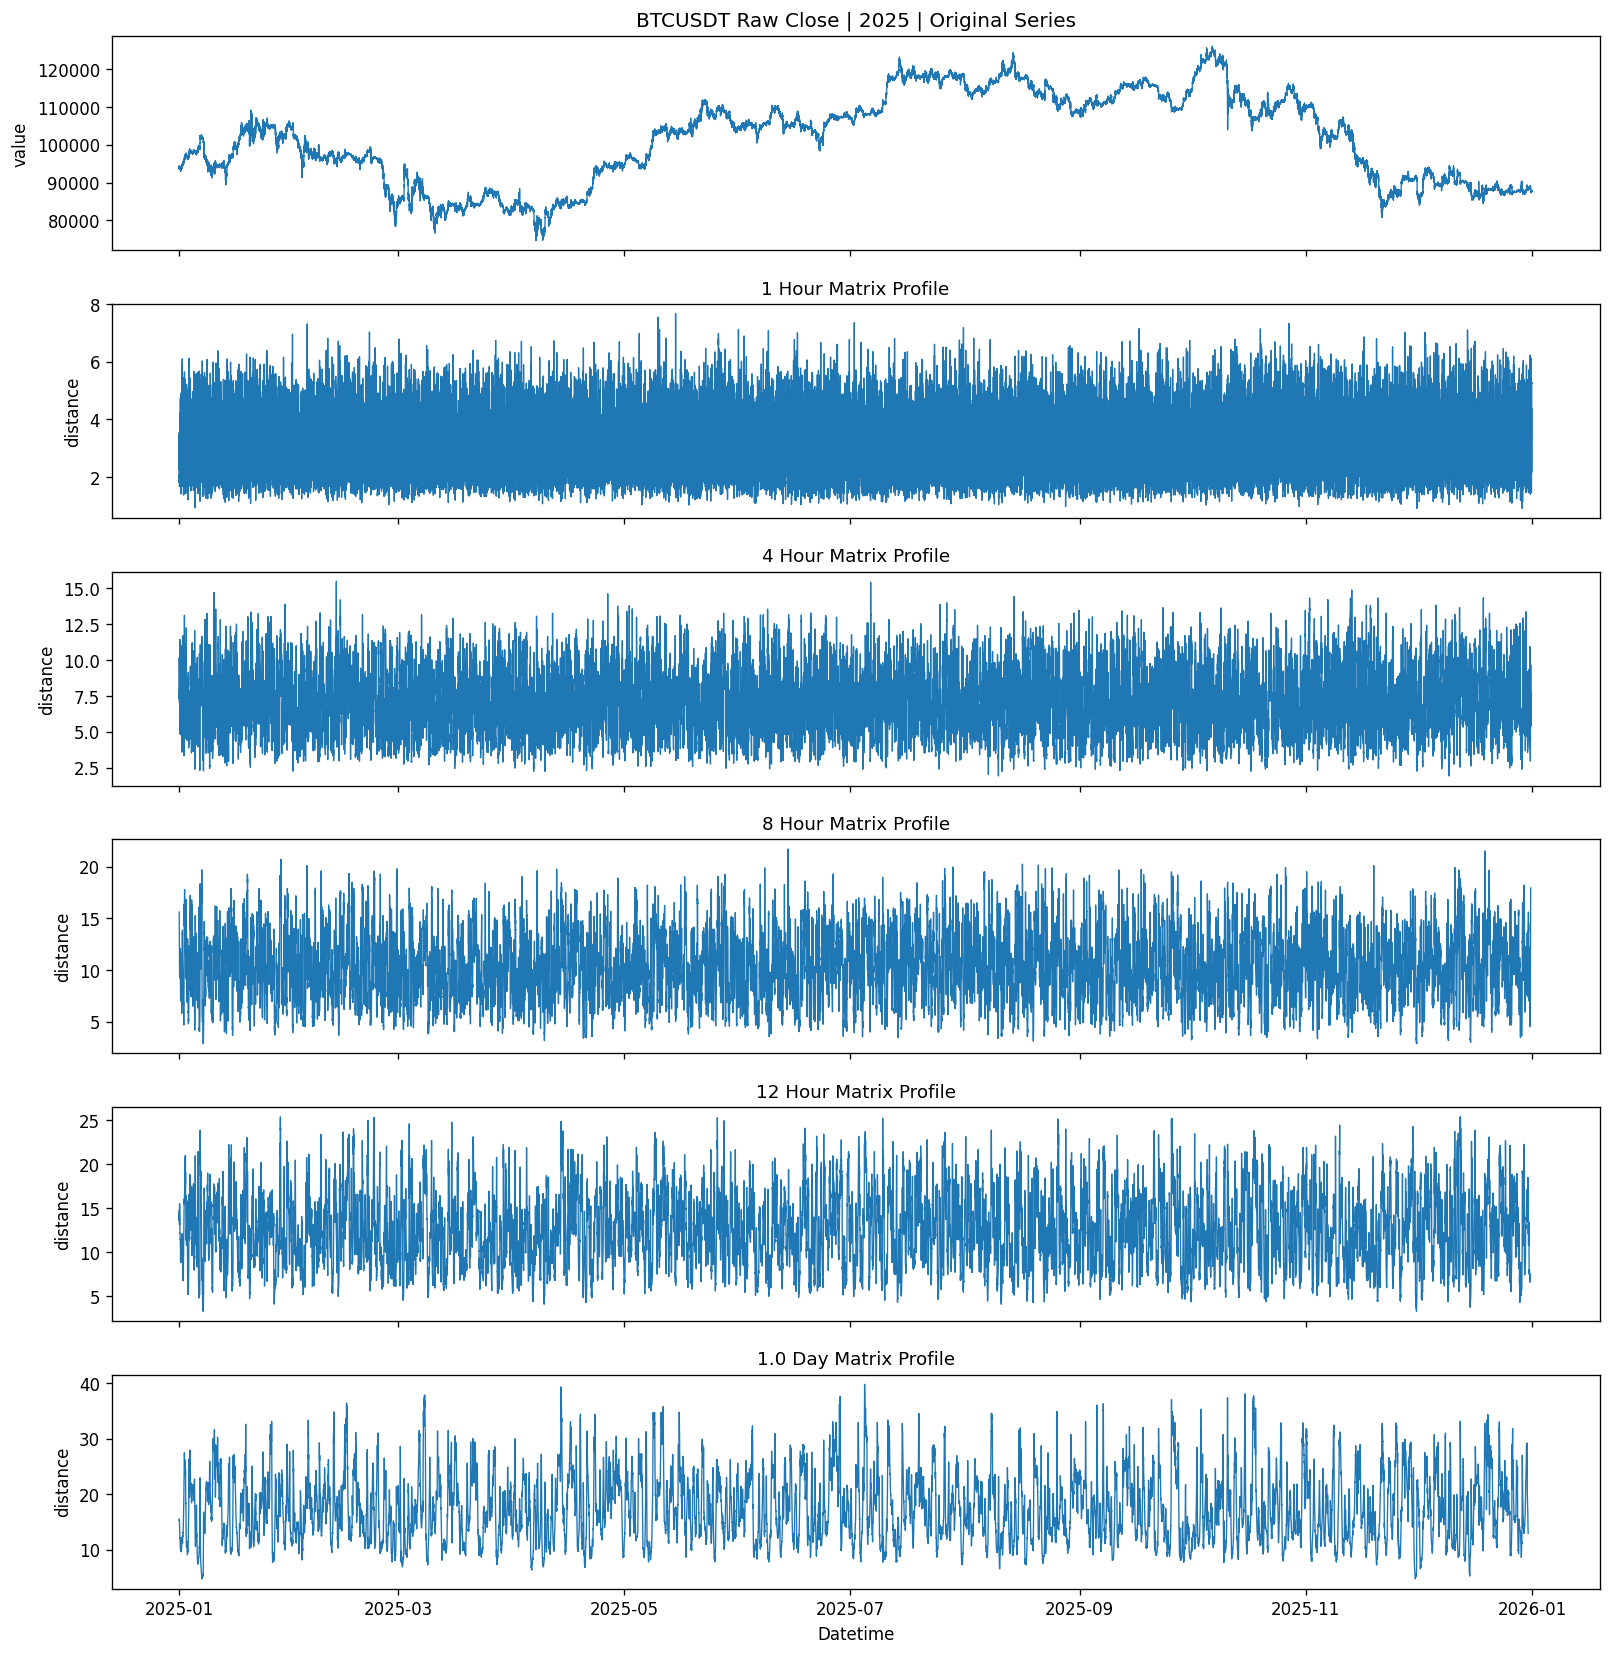

In [16]:
raw_col = "close"
df_raw = prepare_univariate_series(df, raw_col)

freq_min = infer_freq_minutes(df_raw)
print("Raw close rows:", len(df_raw), "| inferred frequency in minutes:", freq_min)

raw_profiles = {}
raw_motif_tables = {}

for m in WINDOWS_RAW_CLOSE:
    if len(df_raw) <= m + 5:
        print(f"Skipping raw close m={m}: insufficient data")
        continue

    print(f"Computing raw close STUMP, m={m} ...")
    mp = compute_stump_profile(df_raw[raw_col].to_numpy(), m)
    raw_profiles[m] = profile_values_from_stump(mp)

    motifs = extract_top_k_motifs_univariate(
        mp=mp,
        timestamps=df_raw["timestamp"],
        m=m,
        top_k=TOP_K,
        min_sep_multiplier=MIN_SEPARATION_MULTIPLIER,
    )
    motifs = annotate_motif_regimes(motifs, df)
    motifs["representation"] = f"raw_close_m{m}"
    raw_motif_tables[m] = motifs

    motifs.to_csv(TABLE_DIR / f"raw_close_motifs_m{m}.csv", index=False)

plot_multiscale_profiles(
    timestamps=df_raw["timestamp"],
    signal=df_raw[raw_col],
    profiles=raw_profiles,
    title=f"{ASSET} Raw Close | {YEAR}",
    save_path=FIG_DIR / "raw_close_multiscale_profiles.png",
    freq_minutes=freq_min or 1.0,
)

In [17]:
selected_raw_window = max(raw_motif_tables.keys()) if raw_motif_tables else None

if selected_raw_window is not None:
    display(raw_motif_tables[selected_raw_window].head(TOP_K))
else:
    print("No raw close motif table available.")

,rank,window_size,motif_index,neighbor_index,motif_start,motif_end,neighbor_start,neighbor_end,profile_value,motif_regime,neighbor_regime,same_regime_flag,representation
0,1,1440,480273,8842,2025-11-30 12:33:00+00:00,2025-12-01 12:32:00+00:00,2025-01-07 03:22:00+00:00,2025-01-08 03:21:00+00:00,4.742861,low_vol,low_vol,True,raw_close_m1440
1,2,1440,318782,482272,2025-08-10 09:02:00+00:00,2025-08-11 09:01:00+00:00,2025-12-01 21:52:00+00:00,2025-12-02 21:51:00+00:00,6.555952,low_vol,high_vol,False,raw_close_m1440
2,3,1440,86663,141429,2025-03-02 04:23:00+00:00,2025-03-03 04:22:00+00:00,2025-04-09 05:09:00+00:00,2025-04-10 05:08:00+00:00,6.913122,mid_vol,high_vol,False,raw_close_m1440
3,4,1440,465270,329050,2025-11-20 02:30:00+00:00,2025-11-21 02:29:00+00:00,2025-08-17 12:10:00+00:00,2025-08-18 12:09:00+00:00,7.290127,high_vol,low_vol,False,raw_close_m1440
4,5,1440,123513,96579,2025-03-27 18:33:00+00:00,2025-03-28 18:32:00+00:00,2025-03-09 01:39:00+00:00,2025-03-10 01:38:00+00:00,7.292658,mid_vol,mid_vol,True,raw_close_m1440
5,6,1440,304318,137177,2025-07-31 07:58:00+00:00,2025-08-01 07:57:00+00:00,2025-04-06 06:17:00+00:00,2025-04-07 06:16:00+00:00,7.312666,low_vol,low_vol,True,raw_close_m1440
6,7,1440,36278,405895,2025-01-26 04:38:00+00:00,2025-01-27 04:37:00+00:00,2025-10-09 20:55:00+00:00,2025-10-10 20:54:00+00:00,7.722436,mid_vol,mid_vol,True,raw_close_m1440
7,8,1440,390276,157639,2025-09-29 00:36:00+00:00,2025-09-30 00:35:00+00:00,2025-04-20 11:19:00+00:00,2025-04-21 11:18:00+00:00,7.735889,mid_vol,mid_vol,True,raw_close_m1440
8,9,1440,449581,229057,2025-11-09 05:01:00+00:00,2025-11-10 05:00:00+00:00,2025-06-09 01:37:00+00:00,2025-06-10 01:36:00+00:00,7.778052,mid_vol,mid_vol,True,raw_close_m1440
9,10,1440,264827,82699,2025-07-03 21:47:00+00:00,2025-07-04 21:46:00+00:00,2025-02-27 10:19:00+00:00,2025-02-28 10:18:00+00:00,7.799184,low_vol,high_vol,False,raw_close_m1440


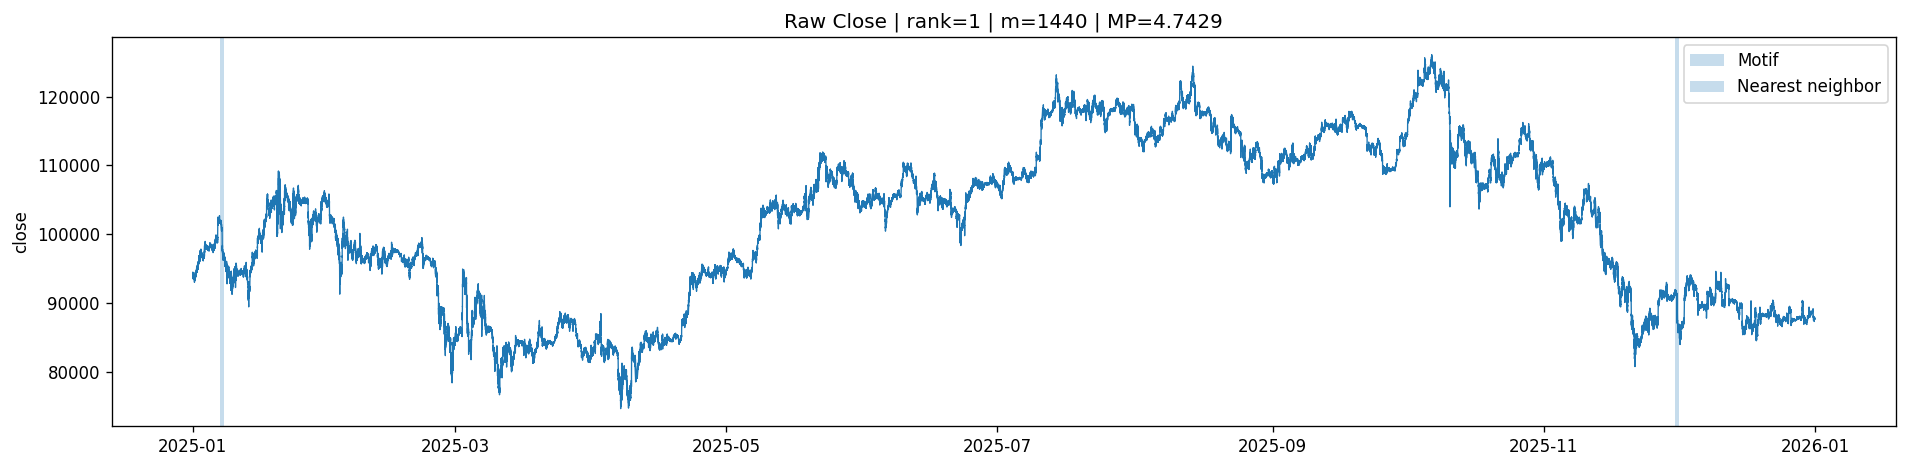

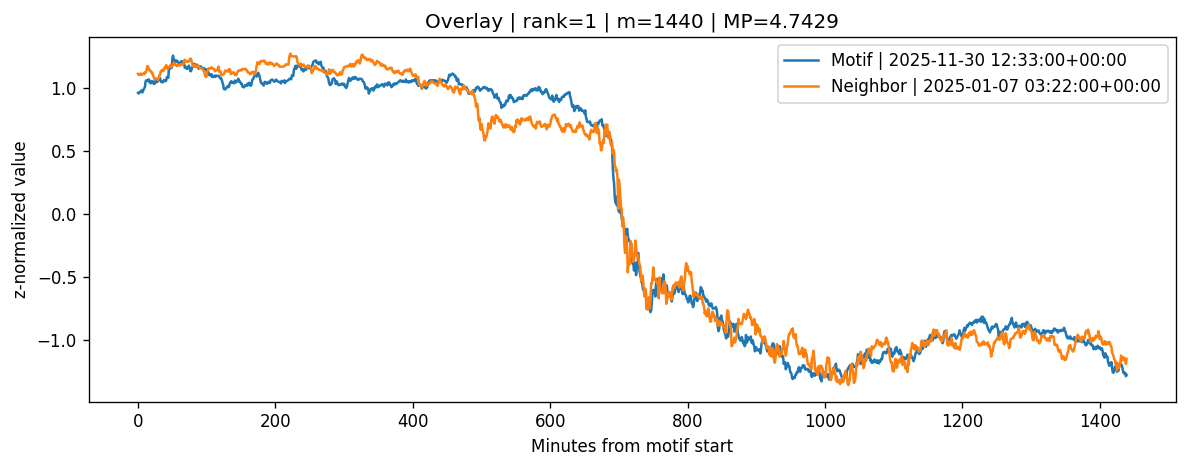

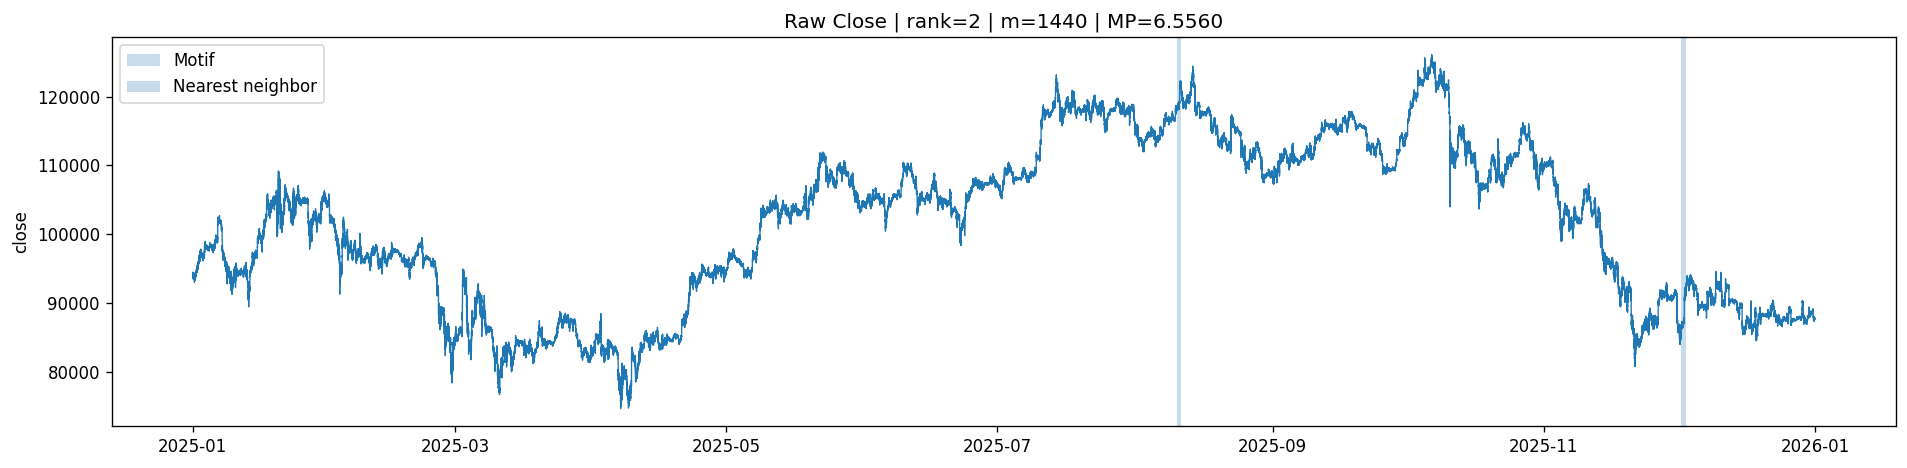

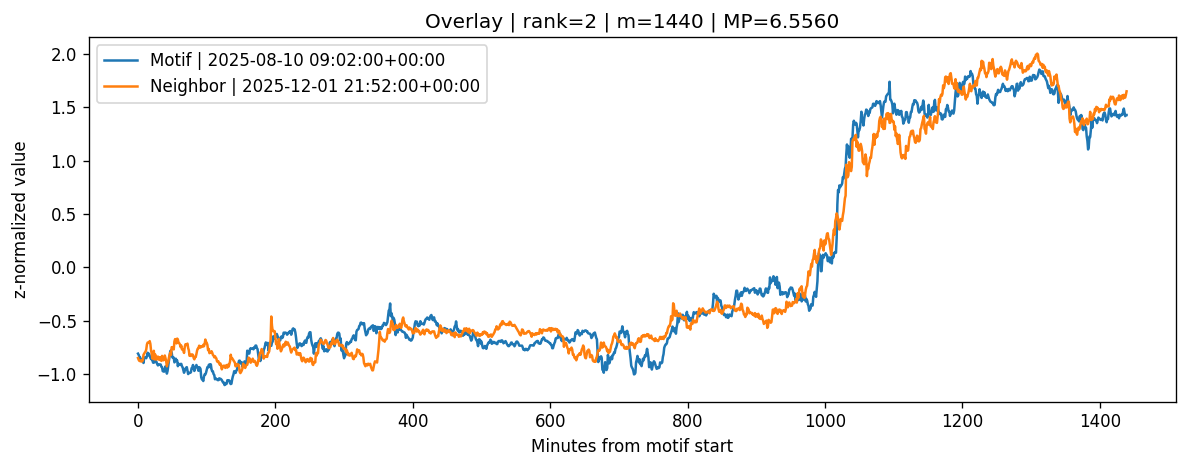

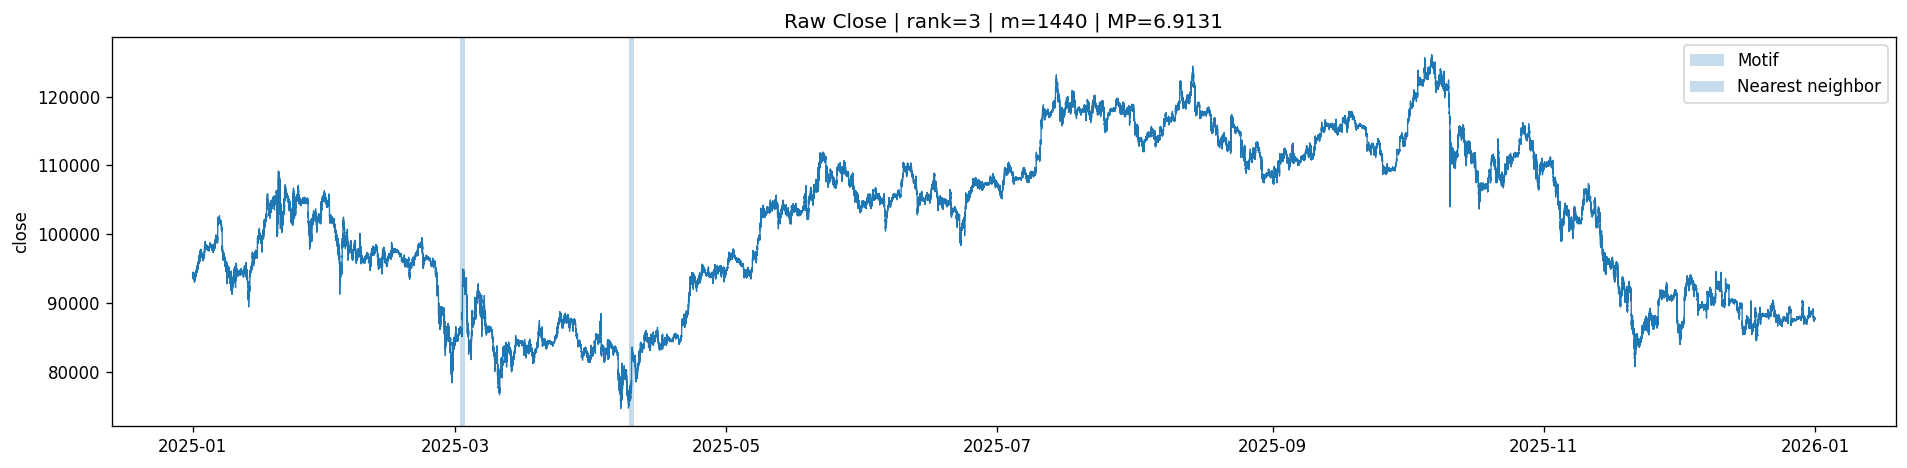

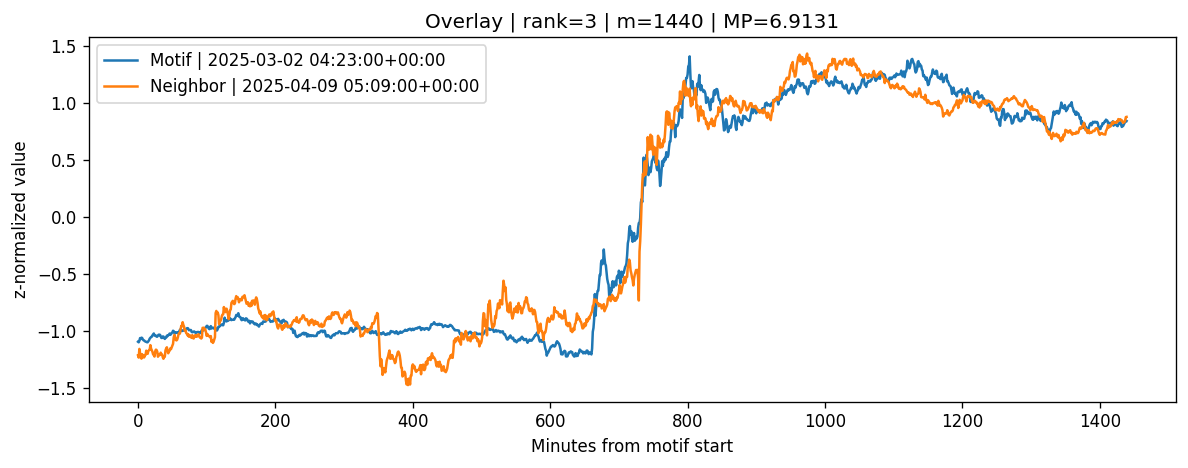

In [18]:
if selected_raw_window is not None and not raw_motif_tables[selected_raw_window].empty:
    for _, row in raw_motif_tables[selected_raw_window].head(3).iterrows():
        rank = int(row["rank"])
        plot_motif_highlight(
            df_signal=df_raw,
            value_col=raw_col,
            motif_row=row,
            title_prefix="Raw Close",
            save_path=FIG_DIR / f"raw_close_m{selected_raw_window}_rank{rank}_highlight.png",
        )
        plot_univariate_motif_overlay(
            df_signal=df_raw,
            value_col=raw_col,
            motif_row=row,
            save_path=FIG_DIR / f"raw_close_m{selected_raw_window}_rank{rank}_overlay.png",
        )

## Engineered Univariate Matrix Profiles

This section computes a separate univariate Matrix Profile for each engineered one-minute feature.


Feature: log_return | usable rows: 525600
Computing log_return STUMP, m=60 ...
Computing log_return STUMP, m=240 ...
Computing log_return STUMP, m=480 ...
Computing log_return STUMP, m=720 ...
Computing log_return STUMP, m=1440 ...


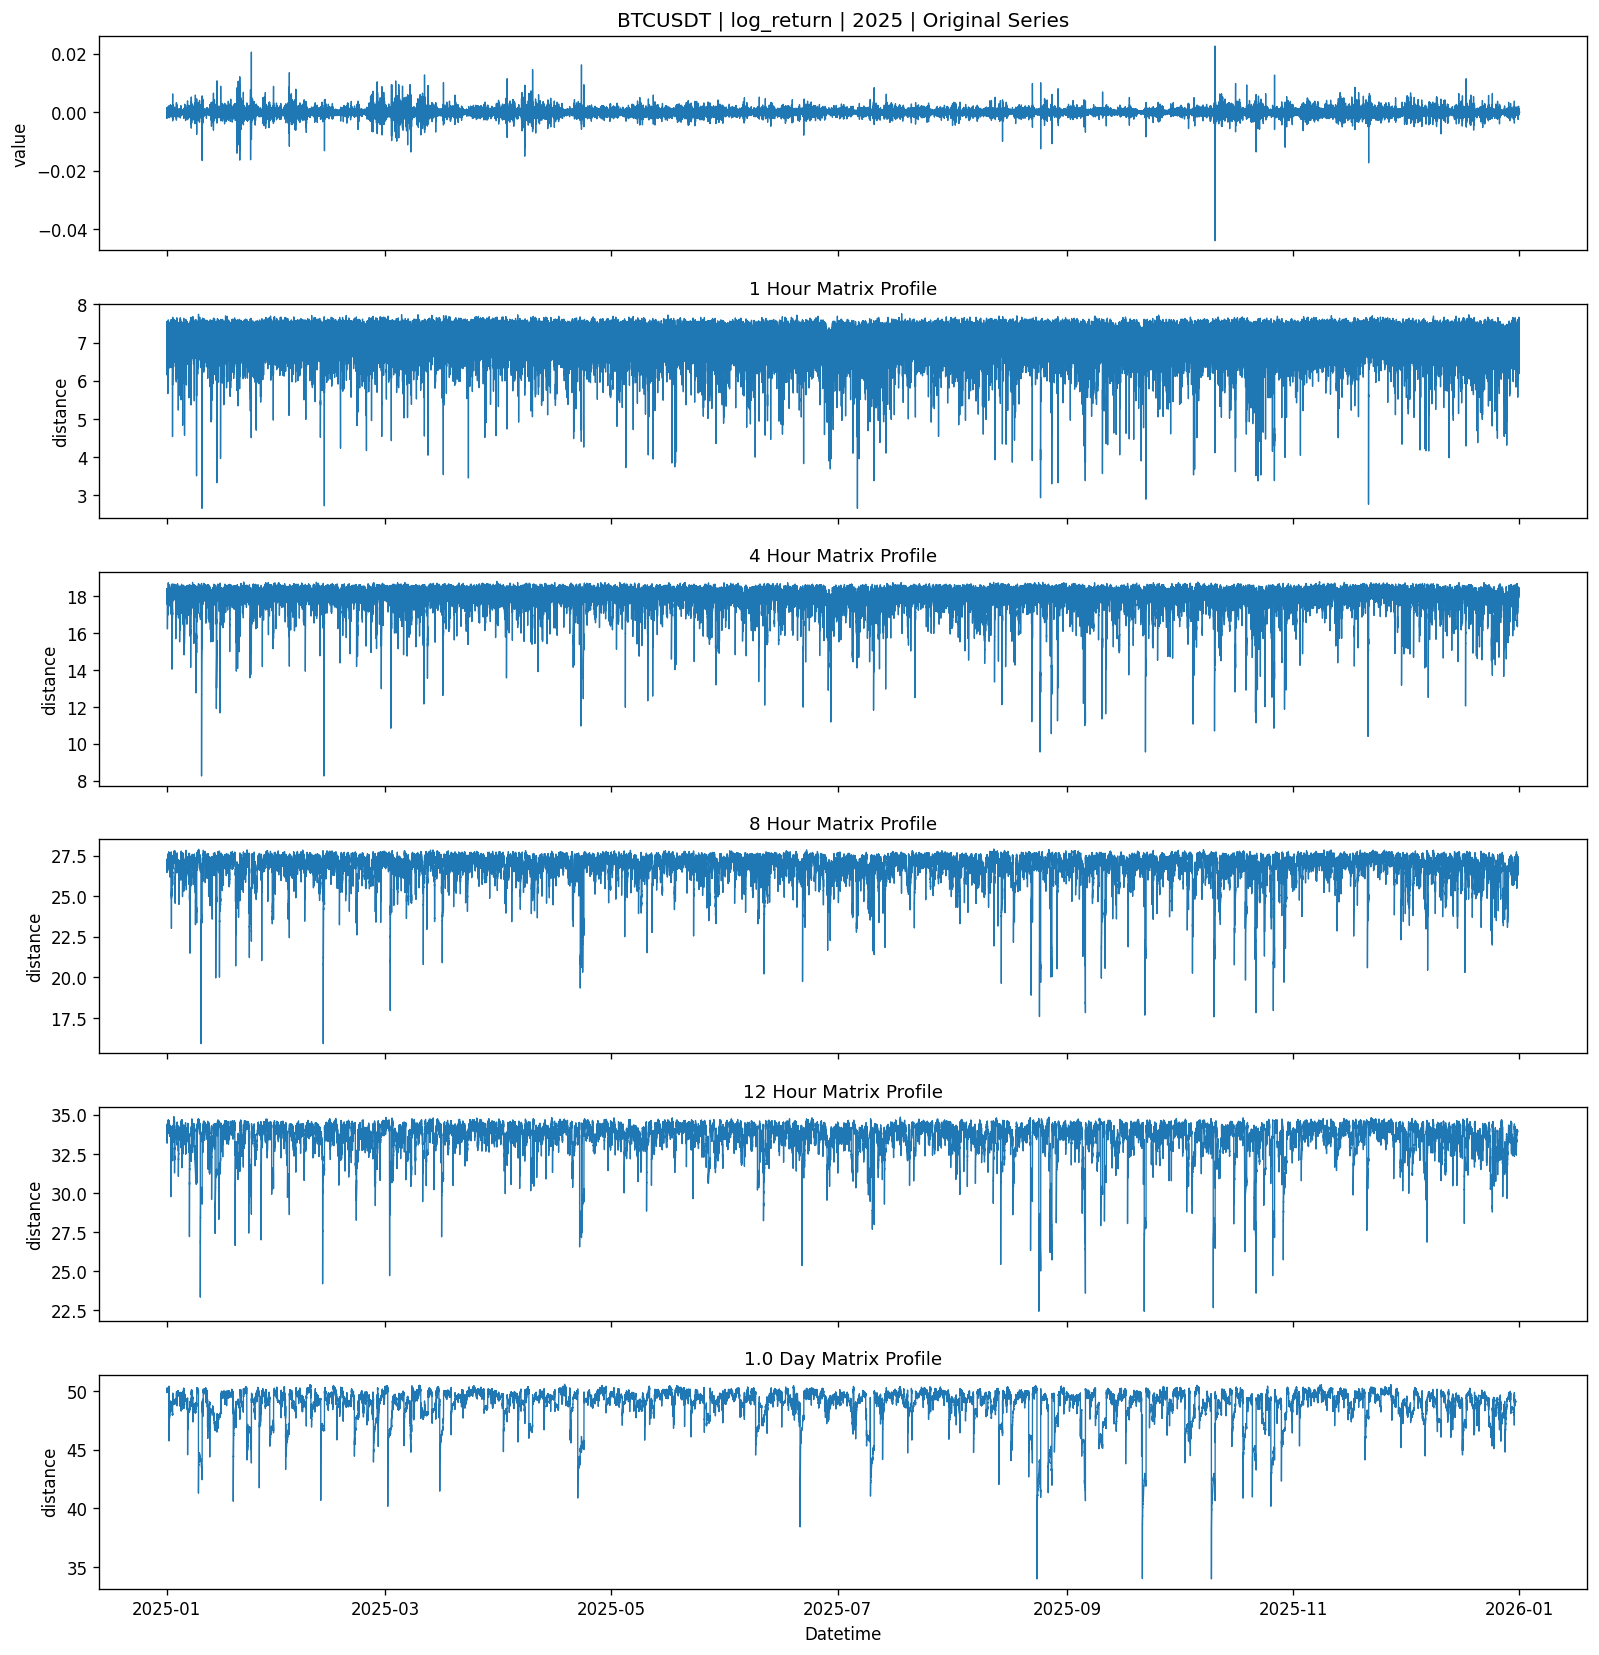


Feature: rolling_volatility | usable rows: 525600
Computing rolling_volatility STUMP, m=60 ...
Computing rolling_volatility STUMP, m=240 ...
Computing rolling_volatility STUMP, m=480 ...
Computing rolling_volatility STUMP, m=720 ...
Computing rolling_volatility STUMP, m=1440 ...


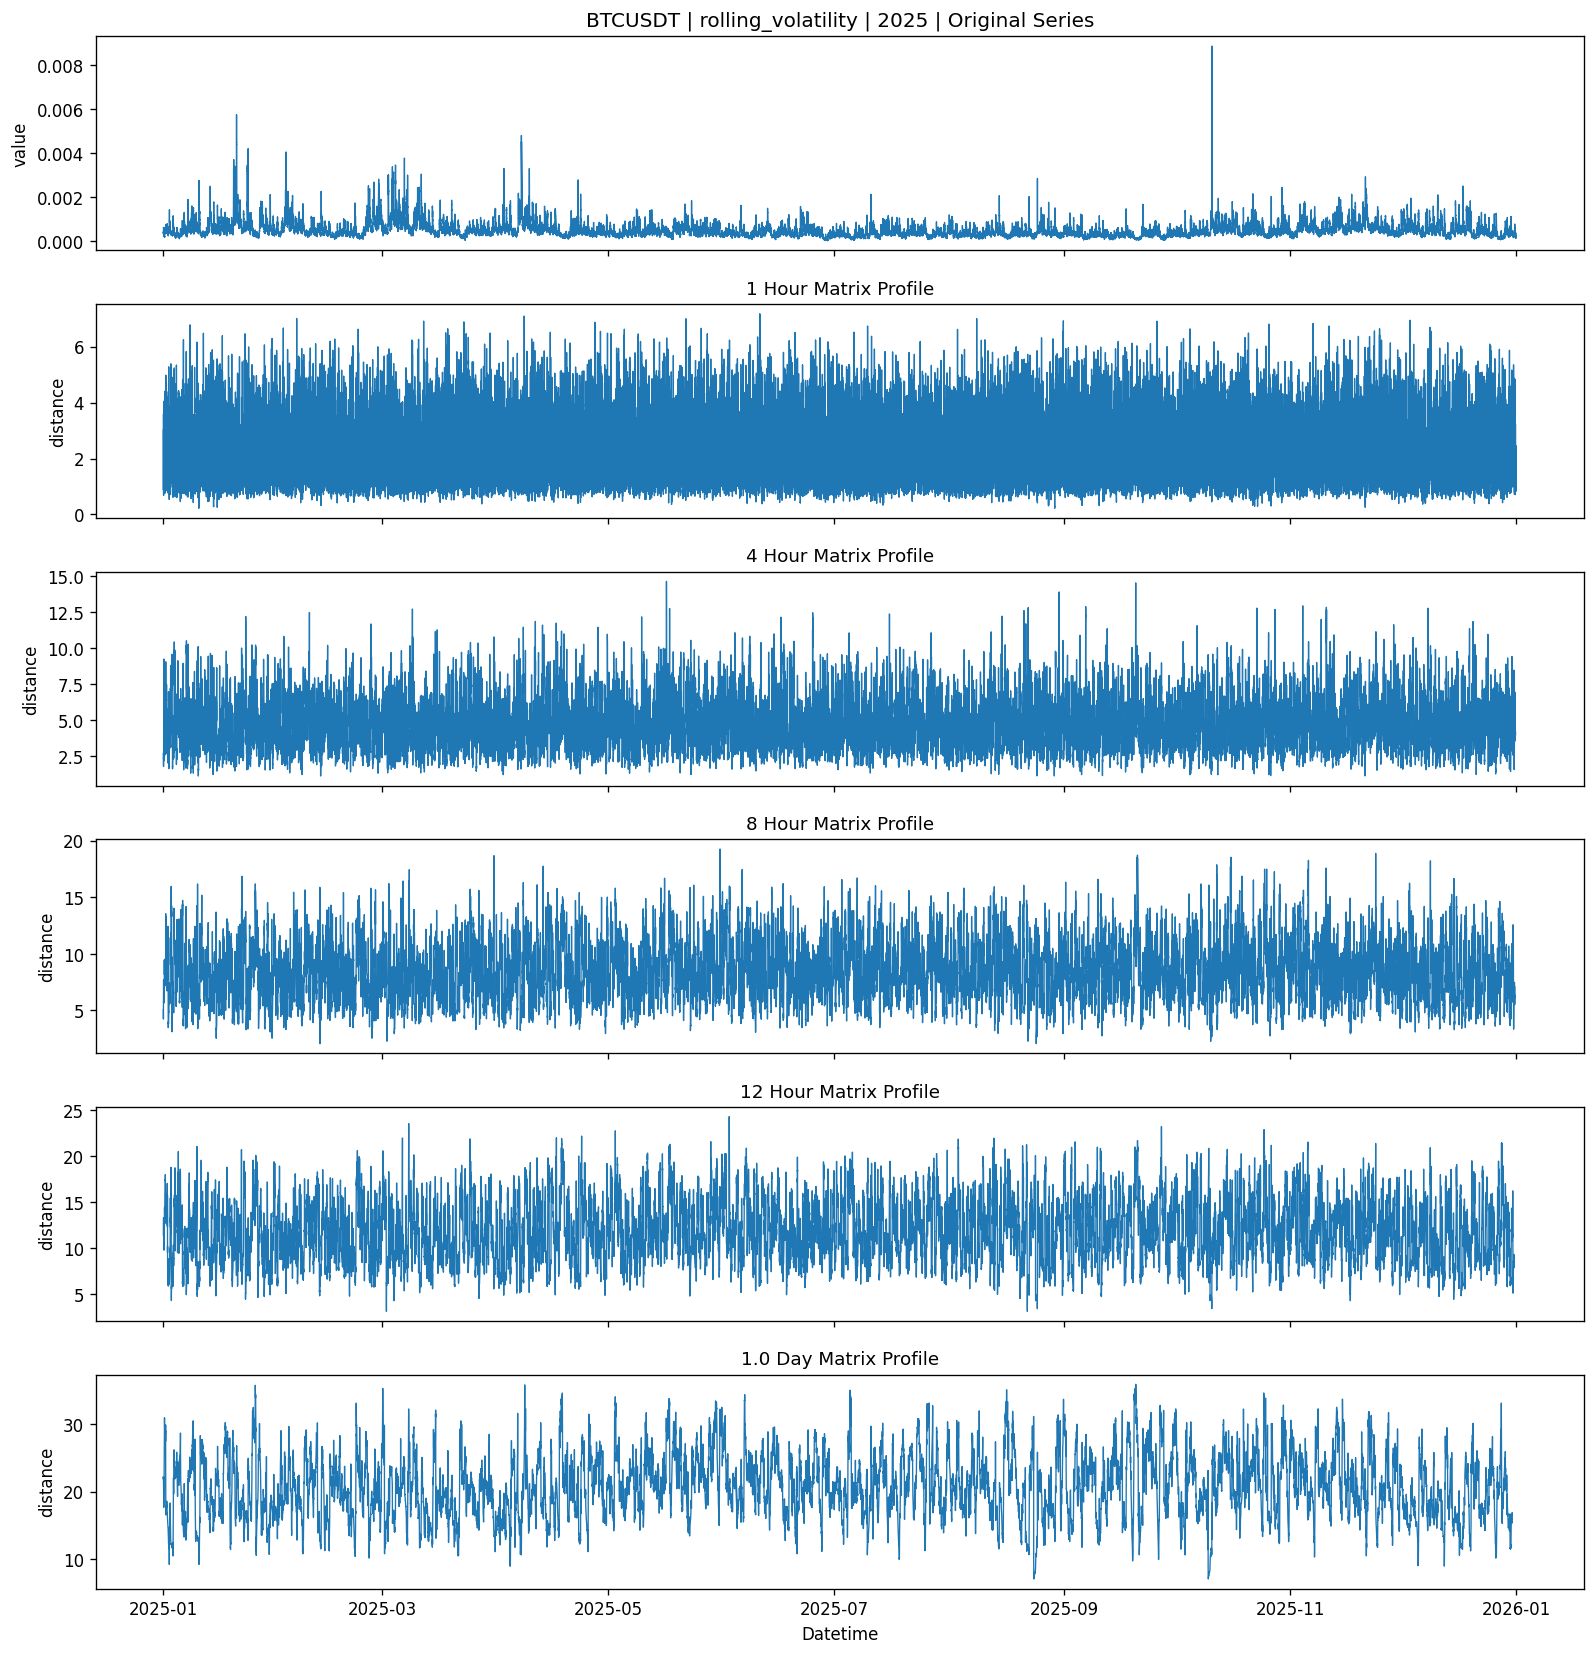


Feature: hl_range | usable rows: 525600
Computing hl_range STUMP, m=60 ...
Computing hl_range STUMP, m=240 ...
Computing hl_range STUMP, m=480 ...
Computing hl_range STUMP, m=720 ...
Computing hl_range STUMP, m=1440 ...


In [ ]:
univariate_results = {}

for feat in available_features:
    df_feat = prepare_univariate_series(df, feat)
    if len(df_feat) < 1000:
        print(f"Skipping feature {feat}: too few usable rows")
        continue

    print(f"\nFeature: {feat} | usable rows: {len(df_feat)}")
    feat_profiles = {}
    feat_motif_tables = {}

    for m in WINDOWS_UNIVARIATE:
        if len(df_feat) <= m + 5:
            print(f"Skipping {feat}, m={m}: insufficient data")
            continue

        print(f"Computing {feat} STUMP, m={m} ...")
        mp = compute_stump_profile(df_feat[feat].to_numpy(), m)
        feat_profiles[m] = profile_values_from_stump(mp)

        motifs = extract_top_k_motifs_univariate(
            mp=mp,
            timestamps=df_feat["timestamp"],
            m=m,
            top_k=TOP_K,
            min_sep_multiplier=MIN_SEPARATION_MULTIPLIER,
        )
        motifs = annotate_motif_regimes(motifs, df)
        motifs["representation"] = f"{feat}_m{m}"
        feat_motif_tables[m] = motifs

        motifs.to_csv(TABLE_DIR / f"{feat}_motifs_m{m}.csv", index=False)

    univariate_results[feat] = {
        "df": df_feat,
        "profiles": feat_profiles,
        "motif_tables": feat_motif_tables,
    }

    plot_multiscale_profiles(
        timestamps=df_feat["timestamp"],
        signal=df_feat[feat],
        profiles=feat_profiles,
        title=f"{ASSET} | {feat} | {YEAR}",
        save_path=FIG_DIR / f"{feat}_multiscale_profiles.png",
        freq_minutes=1.0,
    )

In [ ]:
if not univariate_results:
    raise ValueError("No engineered univariate results are available. Check feature construction and missingness.")

FEATURE_TO_REVIEW = "log_return" if "log_return" in univariate_results else list(univariate_results.keys())[0]

feat_pack = univariate_results[FEATURE_TO_REVIEW]
candidate_windows = list(feat_pack["motif_tables"].keys())
selected_feat_window = candidate_windows[-1] if candidate_windows else None

print("Reviewing feature:", FEATURE_TO_REVIEW)
print("Selected window:", selected_feat_window)

if selected_feat_window is not None:
    display(feat_pack["motif_tables"][selected_feat_window].head(TOP_K))
else:
    print("No motif table available for selected engineered feature.")

In [ ]:
if selected_feat_window is not None:
    df_feat = feat_pack["df"]
    motif_df = feat_pack["motif_tables"][selected_feat_window]

    for _, row in motif_df.head(3).iterrows():
        rank = int(row["rank"])
        plot_motif_highlight(
            df_signal=df_feat,
            value_col=FEATURE_TO_REVIEW,
            motif_row=row,
            title_prefix=FEATURE_TO_REVIEW,
            save_path=FIG_DIR / f"{FEATURE_TO_REVIEW}_m{selected_feat_window}_rank{rank}_highlight.png",
        )
        plot_univariate_motif_overlay(
            df_signal=df_feat,
            value_col=FEATURE_TO_REVIEW,
            motif_row=row,
            save_path=FIG_DIR / f"{FEATURE_TO_REVIEW}_m{selected_feat_window}_rank{rank}_overlay.png",
        )

## Multivariate MSTUMP

This section computes multivariate motif discovery over the selected engineered features.

In [ ]:
multi_features = [f for f in ["log_return", "rolling_volatility", "hl_range", "volume_zscore"] if f in df.columns]
print("Multivariate features:", multi_features)

if len(multi_features) < 2:
    raise ValueError("Need at least two available features for multivariate MSTUMP.")

df_multi = prepare_multivariate_df(df, multi_features)
if len(df_multi) < 1000:
    raise ValueError("Too few complete rows for multivariate MSTUMP after dropping missing feature values.")

display(df_multi.head())
print("Rows in multivariate dataframe:", len(df_multi))

In [ ]:
multivariate_profiles = {}
multivariate_motif_tables = {}

X = df_multi[multi_features].to_numpy(dtype=float).T  # shape: (dimensions, time)

for m in WINDOWS_MULTIVARIATE:
    if X.shape[1] <= m + 5:
        print(f"Skipping multivariate m={m}: insufficient data")
        continue

    print(f"Computing multivariate MSTUMP, m={m} ...")
    P, I = compute_mstump_profile(X, m=m)
    full_profile = np.asarray(P[-1], dtype=float)
    multivariate_profiles[m] = full_profile

    motifs = extract_top_k_motifs_multivariate(
        P=P,
        I=I,
        timestamps=df_multi["timestamp"],
        m=m,
        top_k=TOP_K,
        min_sep_multiplier=MIN_SEPARATION_MULTIPLIER,
    )
    motifs = annotate_motif_regimes(motifs, df)
    motifs["representation"] = f"multivariate_m{m}"
    multivariate_motif_tables[m] = motifs

    motifs.to_csv(TABLE_DIR / f"multivariate_motifs_m{m}.csv", index=False)

plot_multiscale_profiles(
    timestamps=df_multi["timestamp"],
    signal=df_multi["log_return"] if "log_return" in df_multi.columns else df_multi[multi_features[0]],
    profiles=multivariate_profiles,
    title=f"{ASSET} Multivariate MSTUMP | full-dimensional profile | {YEAR}",
    save_path=FIG_DIR / "multivariate_multiscale_profiles.png",
    freq_minutes=1.0,
)

In [ ]:
selected_multi_window = max(multivariate_motif_tables.keys()) if multivariate_motif_tables else None

if selected_multi_window is not None:
    display(multivariate_motif_tables[selected_multi_window].head(TOP_K))
else:
    print("No multivariate motif table available.")

In [ ]:
if selected_multi_window is not None and not multivariate_motif_tables[selected_multi_window].empty:
    for _, row in multivariate_motif_tables[selected_multi_window].head(3).iterrows():
        rank = int(row["rank"])
        plot_multivariate_motif_panel(
            df_multi=df_multi,
            features=multi_features,
            motif_row=row,
            save_path=FIG_DIR / f"multivariate_m{selected_multi_window}_rank{rank}_panel.png",
        )

## Common Motif Matching

This section builds one occurrence table per representation and identifies motifs that recur within the chosen timestamp tolerance.

In [ ]:
occurrence_tables = {}

for m, motif_df in raw_motif_tables.items():
    rep_name = f"raw_close_m{m}"
    occurrence_tables[rep_name] = build_occurrence_table(motif_df, rep_name)

for feat, pack in univariate_results.items():
    for m, motif_df in pack["motif_tables"].items():
        rep_name = f"{feat}_m{m}"
        occurrence_tables[rep_name] = build_occurrence_table(motif_df, rep_name)

for m, motif_df in multivariate_motif_tables.items():
    rep_name = f"multivariate_m{m}"
    occurrence_tables[rep_name] = build_occurrence_table(motif_df, rep_name)

print("Total occurrence tables:", len(occurrence_tables))
print("Non-empty occurrence tables:", sum(not t.empty for t in occurrence_tables.values()))

In [ ]:
common_motifs_df = find_common_motifs(
    occurrence_tables=occurrence_tables,
    tolerance_minutes=COMMON_MOTIF_TOLERANCE_MINUTES,
)

display(common_motifs_df.head(50))
common_motifs_df.to_csv(TABLE_DIR / "common_motifs_across_representations.csv", index=False)

In [ ]:
if not common_motifs_df.empty:
    common_motifs_df["date_a"] = pd.to_datetime(common_motifs_df["start_a"], utc=True).dt.date
    date_summary = (
        common_motifs_df.groupby("date_a")
        .agg(
            n_matches=("gap_minutes", "size"),
            median_gap_minutes=("gap_minutes", "median"),
            reps_a=("rep_a", lambda x: ", ".join(sorted(set(x)))),
            reps_b=("rep_b", lambda x: ", ".join(sorted(set(x)))),
        )
        .sort_values(["n_matches", "median_gap_minutes"], ascending=[False, True])
        .reset_index()
    )
    display(date_summary.head(20))
    date_summary.to_csv(TABLE_DIR / "common_motif_date_summary.csv", index=False)
else:
    date_summary = pd.DataFrame()
    print("No common motifs found under the current tolerance.")

## External Event Matching

This section connects motif timestamps to a thesis event calendar. If no external CSV exists yet, the notebook uses clearly labeled placeholder events so the matching code can still be tested.

In [ ]:
events_df = load_external_events()
display(events_df)

all_occurrences = pd.concat(
    [v for v in occurrence_tables.values() if not v.empty],
    ignore_index=True,
) if occurrence_tables else pd.DataFrame()

event_matches = match_motifs_to_events(
    all_occurrences,
    events_df,
    tolerance_hours=EVENT_TOLERANCE_HOURS,
)
display(event_matches.head(50))

event_matches.to_csv(TABLE_DIR / "motif_external_event_matches.csv", index=False)

In [ ]:
def plot_regime_overlay(
    df: pd.DataFrame,
    value_col: str = "close",
    regime_col: str = "vol_regime",
    motif_occurrences: Optional[pd.DataFrame] = None,
    start: Optional[str] = None,
    end: Optional[str] = None,
    save_path: Optional[Path] = None,
):
    plot_df = df.copy()

    if start is not None:
        plot_df = plot_df[plot_df["timestamp"] >= pd.Timestamp(start, tz="UTC")]
    if end is not None:
        plot_df = plot_df[plot_df["timestamp"] <= pd.Timestamp(end, tz="UTC")]

    if plot_df.empty:
        raise ValueError("No rows available for requested regime overlay period.")

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(plot_df["timestamp"], plot_df[value_col], linewidth=0.8, color="black")

    regime_colors = {
        "low_vol": "green",
        "mid_vol": "gold",
        "high_vol": "red",
        "unknown": "gray",
    }

    if regime_col in plot_df.columns:
        changes = plot_df[regime_col].ne(plot_df[regime_col].shift()).cumsum()
        for _, g in plot_df.groupby(changes):
            reg = g[regime_col].iloc[0]
            ax.axvspan(
                g["timestamp"].iloc[0],
                g["timestamp"].iloc[-1],
                alpha=0.08,
                color=regime_colors.get(reg, "gray"),
            )

    if motif_occurrences is not None and not motif_occurrences.empty:
        start_ts = plot_df["timestamp"].min()
        end_ts = plot_df["timestamp"].max()
        for _, r in motif_occurrences.iterrows():
            if start_ts <= r["start"] <= end_ts:
                ax.axvline(r["start"], linestyle="--", alpha=0.4)

    ax.set_title(f"{ASSET} | {value_col} with volatility regimes")
    ax.set_ylabel(value_col)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

In [ ]:
plot_regime_overlay(
    df=df,
    value_col="close" if "close" in df.columns else df.columns[1],
    regime_col="vol_regime",
    motif_occurrences=all_occurrences.head(30) if not all_occurrences.empty else None,
    start="2025-01-01",
    end="2025-03-31",
    save_path=FIG_DIR / "regime_overlay_q1.png",
)

## Master Motif Log

This table is the main thesis artifact from the notebook. It combines raw, engineered univariate, and multivariate motif outputs into one structured CSV.

In [ ]:
motif_logs = []

for m, motif_df in raw_motif_tables.items():
    if not motif_df.empty:
        x = motif_df.copy()
        x["analysis_type"] = "raw_univariate"
        x["feature_set"] = "close"
        motif_logs.append(x)

for feat, pack in univariate_results.items():
    for m, motif_df in pack["motif_tables"].items():
        if not motif_df.empty:
            x = motif_df.copy()
            x["analysis_type"] = "engineered_univariate"
            x["feature_set"] = feat
            motif_logs.append(x)

for m, motif_df in multivariate_motif_tables.items():
    if not motif_df.empty:
        x = motif_df.copy()
        x["analysis_type"] = "multivariate"
        x["feature_set"] = ",".join(multi_features)
        motif_logs.append(x)

master_motif_log = pd.concat(motif_logs, ignore_index=True) if motif_logs else pd.DataFrame()

display(master_motif_log.head(30))
master_motif_log.to_csv(TABLE_DIR / "master_motif_log.csv", index=False)

In [ ]:
summary_rows = []

for m, motif_df in raw_motif_tables.items():
    summary_rows.append({
        "analysis_type": "raw_univariate",
        "representation": f"raw_close_m{m}",
        "n_motifs": len(motif_df),
        "median_profile_value": motif_df["profile_value"].median() if not motif_df.empty else np.nan,
    })

for feat, pack in univariate_results.items():
    for m, motif_df in pack["motif_tables"].items():
        summary_rows.append({
            "analysis_type": "engineered_univariate",
            "representation": f"{feat}_m{m}",
            "n_motifs": len(motif_df),
            "median_profile_value": motif_df["profile_value"].median() if not motif_df.empty else np.nan,
        })

for m, motif_df in multivariate_motif_tables.items():
    summary_rows.append({
        "analysis_type": "multivariate",
        "representation": f"multivariate_m{m}",
        "n_motifs": len(motif_df),
        "median_profile_value": motif_df["profile_value"].median() if not motif_df.empty else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["analysis_type", "representation"]).reset_index(drop=True)
display(summary_df)

summary_df.to_csv(TABLE_DIR / "summary_overview.csv", index=False)

## Interpretation Notes

Use this section to write thesis-ready observations after running the notebook.

### 1. Raw close motifs
- Which window sizes produced visually interpretable motifs?
- Did raw-close motifs mostly reflect trend shape, shock-recovery shape, or volatility bursts?

### 2. Engineered univariate motifs
- Which single feature gave the cleanest motifs?
- Did `log_return` capture event-like repeated shocks?
- Did `rolling_volatility` produce stronger regime-linked motifs?
- Did `hl_range` or `volume_zscore` capture market microstructure stress or activity bursts?

### 3. Multivariate motifs
- Did joint motifs look more meaningful than raw univariate motifs?
- Did the multivariate motifs reflect repeated market states rather than only repeated price shapes?
- Were the top motifs concentrated in similar volatility regimes?

### 4. Common motifs across representations
- Which dates repeatedly appeared across raw, engineered, and multivariate discovery?
- These dates are candidates for stronger structural motifs.

### 5. External reality check
- Did top/common motif dates align with identifiable external market events?
- This helps distinguish genuinely meaningful motifs from purely algorithmic repetitions.

### 6. Takeaway for thesis benchmark
- Which representations and window sizes should be advanced into the benchmark stage?
- Which motif settings seem most robust and interpretable?

In [ ]:
config_snapshot = pd.DataFrame([{
    "asset": ASSET,
    "year": YEAR,
    "run_mode": RUN_MODE,
    "debug_rows": DEBUG_ROWS,
    "top_k": TOP_K,
    "windows_raw_close": str(WINDOWS_RAW_CLOSE),
    "windows_univariate": str(WINDOWS_UNIVARIATE),
    "windows_multivariate": str(WINDOWS_MULTIVARIATE),
    "candidate_features": str(CANDIDATE_FEATURES),
    "available_features": str(available_features),
    "multi_features_used": str(multi_features if "multi_features" in locals() else []),
    "common_motif_tolerance_minutes": COMMON_MOTIF_TOLERANCE_MINUTES,
    "event_tolerance_hours": EVENT_TOLERANCE_HOURS,
    "data_path": str(data_path),
    "output_dir": str(OUTPUT_DIR),
}])

display(config_snapshot)
config_snapshot.to_csv(TABLE_DIR / "config_snapshot.csv", index=False)

In [ ]:
# ============================================================
# FINAL EXPORT CELL
# Save all Matrix Profile study outputs in clean readable form
# ============================================================

import json
from pathlib import Path
import numpy as np
import pandas as pd

# ---------------------------
# Export folder structure
# ---------------------------
EXPORT_ROOT = OUTPUT_DIR / "final_exports"
MP_DIR = EXPORT_ROOT / "matrix_profiles"
MOTIF_DIR = EXPORT_ROOT / "motif_tables"
SUMMARY_DIR = EXPORT_ROOT / "summaries"
EVENT_DIR = EXPORT_ROOT / "event_matches"
META_DIR = EXPORT_ROOT / "metadata"

for d in [EXPORT_ROOT, MP_DIR, MOTIF_DIR, SUMMARY_DIR, EVENT_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:", EXPORT_ROOT)


# ---------------------------
# Helper: safe dataframe save
# ---------------------------
def save_df_both(df: pd.DataFrame, path_no_suffix: Path):
    """
    Save DataFrame as both CSV and Parquet when possible.
    CSV is universally readable.
    Parquet is compact and fast for re-loading.
    """
    if df is None:
        return []
    
    saved_paths = []
    csv_path = path_no_suffix.with_suffix(".csv")
    df.to_csv(csv_path, index=False)
    saved_paths.append(csv_path)
    
    try:
        parquet_path = path_no_suffix.with_suffix(".parquet")
        df.to_parquet(parquet_path, index=False)
        saved_paths.append(parquet_path)
    except Exception as e:
        print(f"Warning: could not save parquet for {path_no_suffix.name}: {e}")
    
    return saved_paths


# ---------------------------
# Helper: save numpy profile
# ---------------------------
def save_profile_array(arr, path_no_suffix: Path):
    """
    Save numeric array in both .npy and compressed .npz.
    """
    arr = np.asarray(arr)
    npy_path = path_no_suffix.with_suffix(".npy")
    npz_path = path_no_suffix.with_suffix(".npz")
    np.save(npy_path, arr)
    np.savez_compressed(npz_path, profile=arr)
    return [npy_path, npz_path]


# ---------------------------
# Helper: safe names + manifest records
# ---------------------------
def safe_stem(value) -> str:
    """Return a filesystem-safe filename stem for feature/representation names."""
    text = str(value)
    cleaned = "".join(ch if ch.isalnum() or ch in {"-", "_"} else "_" for ch in text)
    return cleaned.strip("_") or "unnamed"


def record_exports(paths):
    """Record all saved paths in the manifest."""
    for path in paths:
        manifest["exports"].append(str(Path(path)))


# ---------------------------
# Manifest dictionary
# ---------------------------
manifest = {
    "asset": ASSET,
    "year": YEAR,
    "run_mode": RUN_MODE,
    "top_k": TOP_K,
    "windows_raw_close": WINDOWS_RAW_CLOSE,
    "windows_univariate": WINDOWS_UNIVARIATE,
    "windows_multivariate": WINDOWS_MULTIVARIATE,
    "candidate_features": CANDIDATE_FEATURES,
    "available_features": available_features if "available_features" in globals() else [],
    "multi_features_used": multi_features if "multi_features" in globals() else [],
    "common_motif_tolerance_minutes": COMMON_MOTIF_TOLERANCE_MINUTES,
    "exports": []
}


# ============================================================
# 1. SAVE RAW CLOSE MATRIX PROFILES + MOTIF TABLES
# ============================================================
if "raw_profiles" in globals():
    for m, profile_vals in raw_profiles.items():
        base = MP_DIR / f"raw_close_m{m}_profile"
        record_exports(save_profile_array(profile_vals, base))

if "raw_motif_tables" in globals():
    for m, motif_df in raw_motif_tables.items():
        base = MOTIF_DIR / f"raw_close_m{m}_motifs"
        record_exports(save_df_both(motif_df, base))


# ============================================================
# 2. SAVE ENGINEERED UNIVARIATE PROFILES + MOTIF TABLES
# ============================================================
if "univariate_results" in globals():
    for feat, pack in univariate_results.items():
        feat_name = safe_stem(feat)
        feat_profiles = pack.get("profiles", {})
        feat_motif_tables = pack.get("motif_tables", {})

        for m, profile_vals in feat_profiles.items():
            base = MP_DIR / f"{feat_name}_m{m}_profile"
            record_exports(save_profile_array(profile_vals, base))

        for m, motif_df in feat_motif_tables.items():
            base = MOTIF_DIR / f"{feat_name}_m{m}_motifs"
            record_exports(save_df_both(motif_df, base))


# ============================================================
# 3. SAVE MULTIVARIATE FULL-DIMENSIONAL PROFILES + MOTIF TABLES
# ============================================================
if "multivariate_profiles" in globals():
    for m, profile_vals in multivariate_profiles.items():
        base = MP_DIR / f"multivariate_m{m}_full_dimension_profile"
        record_exports(save_profile_array(profile_vals, base))

if "multivariate_motif_tables" in globals():
    for m, motif_df in multivariate_motif_tables.items():
        base = MOTIF_DIR / f"multivariate_m{m}_motifs"
        record_exports(save_df_both(motif_df, base))


# ============================================================
# 4. SAVE GLOBAL SUMMARY TABLES
# ============================================================
summary_objects = {
    "master_motif_log": globals().get("master_motif_log", None),
    "summary_overview": globals().get("summary_df", None),
    "common_motifs_across_representations": globals().get("common_motifs_df", None),
    "config_snapshot": globals().get("config_snapshot", None),
}

for name, obj in summary_objects.items():
    if isinstance(obj, pd.DataFrame):
        base = SUMMARY_DIR / name
        record_exports(save_df_both(obj, base))

# save date summary if it exists
if "date_summary" in globals() and isinstance(date_summary, pd.DataFrame):
    base = SUMMARY_DIR / "common_motif_date_summary"
    record_exports(save_df_both(date_summary, base))

# save motif-to-event matches if they exist
if "event_matches" in globals() and isinstance(event_matches, pd.DataFrame):
    base = EVENT_DIR / "motif_external_event_matches"
    record_exports(save_df_both(event_matches, base))

# save events table if it exists
if "events_df" in globals() and isinstance(events_df, pd.DataFrame):
    base = EVENT_DIR / "external_events_used"
    record_exports(save_df_both(events_df, base))


# ============================================================
# 5. SAVE METADATA / MANIFEST / DATASET INFO
# ============================================================
dataset_info = {
    "data_path": str(data_path) if "data_path" in globals() else None,
    "rows_in_full_df": int(len(df)) if "df" in globals() else None,
    "timestamp_start": str(df["timestamp"].min()) if "df" in globals() and "timestamp" in df.columns else None,
    "timestamp_end": str(df["timestamp"].max()) if "df" in globals() and "timestamp" in df.columns else None,
    "columns": list(df.columns) if "df" in globals() else [],
    "inferred_freq_minutes": infer_freq_minutes(df) if "df" in globals() else None,
}

dataset_info_path = META_DIR / "dataset_info.json"
manifest_path = META_DIR / "manifest.json"
export_index_path = META_DIR / "EXPORT_INDEX.md"

record_exports([dataset_info_path, manifest_path, export_index_path])

with open(dataset_info_path, "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, indent=2, default=str)

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)


# ============================================================
# 6. HUMAN-READABLE EXPORT INDEX
# ============================================================
index_lines = []
index_lines.append("# Matrix Profile Study Export Index\n")
index_lines.append(f"Asset: {ASSET}\n")
index_lines.append(f"Year: {YEAR}\n")
index_lines.append(f"Run mode: {RUN_MODE}\n")
index_lines.append(f"Top K motifs: {TOP_K}\n")
index_lines.append("\n## Folder structure\n")
index_lines.append(f"- matrix_profiles/: saved MP arrays as .npy and .npz\n")
index_lines.append(f"- motif_tables/: saved motif tables as .csv and .parquet\n")
index_lines.append(f"- summaries/: global summaries and combined logs\n")
index_lines.append(f"- event_matches/: motif/event matches and external events used\n")
index_lines.append(f"- metadata/: manifest and dataset information\n")

index_lines.append("\n## Available exports\n")
for item in manifest["exports"]:
    index_lines.append(f"- {item}\n")

with open(export_index_path, "w", encoding="utf-8") as f:
    f.writelines(index_lines)


# ============================================================
# 7. FINAL CONSOLE SUMMARY
# ============================================================
print("\nExport complete.")
print("Main export root:", EXPORT_ROOT)
print("Matrix Profiles saved in:", MP_DIR)
print("Motif tables saved in:", MOTIF_DIR)
print("Summaries saved in:", SUMMARY_DIR)
print("Metadata saved in:", META_DIR)

print("\nSaved files preview:")
for p in sorted(EXPORT_ROOT.rglob("*"))[:40]:
    if p.is_file():
        print("-", p.relative_to(EXPORT_ROOT))